<a href="https://colab.research.google.com/github/HarshalMakode/Movie-Recommendation-System-using-PySpark/blob/main/MovieR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [19]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.1 MB/s eta 0:00:00


In [22]:
from pyngrok import ngrok

ngrok.set_auth_token("3C20db7DcSyAJdRCQ3qL3h693Oj_4BjJo7US2cSmSbYVeSR4L")

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieRecommendation") \
    .getOrCreate()

sc = spark.sparkContext

In [3]:
from google.colab import files
uploaded = files.upload()

Saving IMBD.csv to IMBD.csv


In [13]:
rdd = sc.textFile("IMBD.csv")

header = rdd.first()
rdd = rdd.filter(lambda x: x != header)

In [14]:
import csv

cleaned = rdd.map(lambda x: next(csv.reader([x]))) \
    .filter(lambda x: len(x) > 8) \
    .filter(lambda x: x[5] != '' and x[5] != 'NaN') \
    .filter(lambda x: x[8] != '' and x[8] != 'NaN')

In [15]:
top_movies = cleaned.map(lambda x: (
    x[0], float(x[5])
)).sortBy(lambda x: x[1], ascending=False)

top_movies.take(10)

[('BoJack Horseman', 9.9),
 ('1899', 9.6),
 ('Avatar: The Last Airbender', 9.6),
 ('Dexter', 9.6),
 ("JoJo's Bizarre Adventure", 9.6),
 ('Avatar: The Last Airbender', 9.6),
 ('Stranger Things', 9.6),
 ('Breaking Bad', 9.5),
 ('Avatar: The Last Airbender', 9.5),
 ('Dark', 9.5)]

In [16]:
popular = cleaned.map(lambda x: (
    x[0], int(x[8].replace(",", ""))
)).sortBy(lambda x: x[1], ascending=False)

popular.take(10)

[('The Lord of the Rings: The Fellowship of the Ring', 1844075),
 ('The Lord of the Rings: The Fellowship of the Ring', 1844055),
 ('Breaking Bad', 1831359),
 ('Breaking Bad', 1831340),
 ('The Lord of the Rings: The Return of the King', 1819157),
 ('The Lord of the Rings: The Two Towers', 1642708),
 ('Gladiator', 1481531),
 ('The Departed', 1310171),
 ('Titanic', 1158746),
 ('Stranger Things', 1149902)]

In [17]:
genre_ratings = cleaned.flatMap(lambda x: [
    (g.strip(), (float(x[5]), 1)) for g in x[4].split(",")
])

avg_genre = genre_ratings.reduceByKey(
    lambda a, b: (a[0]+b[0], a[1]+b[1])
).mapValues(lambda x: x[0]/x[1])

avg_genre.collect()

[('Action', 6.8845070422535235),
 ('Comedy', 6.701560837176296),
 ('Drama', 6.9067424643046005),
 ('History', 7.267065868263472),
 ('Horror', 5.803232323232324),
 ('Adventure', 7.073453237410071),
 ('Romance', 6.699352750809062),
 ('Sport', 6.849382716049382),
 ('Sci-Fi', 6.341015624999999),
 ('Documentary', 7.02047697368421),
 ('Music', 6.859813084112147),
 ('Musical', 6.749333333333334),
 ('', 7.175),
 ('Biography', 6.965588235294118),
 ('Crime', 6.88153409090909),
 ('Mystery', 6.8547814207650255),
 ('Animation', 7.1715624999999985),
 ('Fantasy', 6.927016129032259),
 ('Thriller', 6.129746835443039),
 ('Short', 6.6251999999999995),
 ('War', 6.9322580645161285),
 ('Family', 6.6544364508393254),
 ('Reality-TV', 6.891334894613588),
 ('Western', 6.5290322580645155),
 ('Game-Show', 6.968),
 ('Talk-Show', 7.06842105263158),
 ('Film-Noir', 6.966666666666666),
 ('News', 7.068421052631578)]

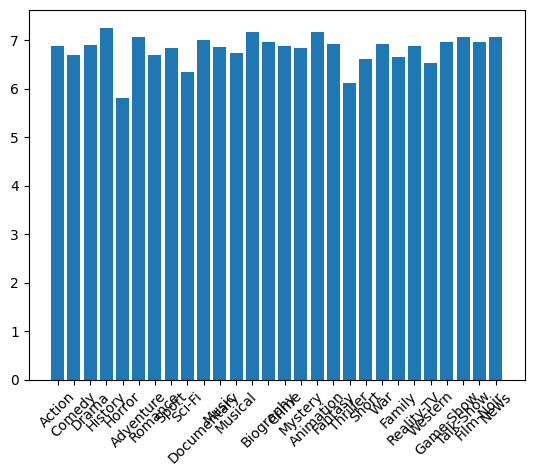

In [18]:
import matplotlib.pyplot as plt

data = avg_genre.collect()

genres = [x[0] for x in data]
ratings = [x[1] for x in data]

plt.bar(genres, ratings)
plt.xticks(rotation=45)
plt.show()

In [25]:
%%writefile app.py
import streamlit as st
import csv

st.title("🎬 Movie Recommendation System")

# Upload dataset
uploaded_file = st.file_uploader("Upload IMBD.csv")

if uploaded_file:
    data = uploaded_file.read().decode("utf-8").splitlines()
    reader = list(csv.reader(data))

    header = reader[0]
    rows = reader[1:]

    # Top rated movies
    movies = []
    for row in rows:
        try:
            if row[5] != '':
                movies.append((row[0], float(row[5])))
        except:
            continue

    movies = sorted(movies, key=lambda x: x[1], reverse=True)

    st.subheader("⭐ Top Movies")
    for m in movies[:10]:
        st.write(f"{m[0]} ⭐ {m[1]}")

Overwriting app.py


In [26]:
!streamlit run app.py &>/dev/null &

In [27]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://immature-lily-casually.ngrok-free.dev" -> "http://localhost:8501">